# 相关性网络热图用于展示多变量之间的相关性，生物信息领域常用来分析物种、基因、环境等因素的相关性强度。


In [4]:
"""使用 Matplotlib 绘制相关性网络热图"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
from matplotlib.font_manager import FontProperties

In [5]:
def load_style():
    """加载样式文件（如果存在），并设置中文字体支持"""
    # 设置样式
    try:
        plt.style.use("scatter.mplstyle")
    except:
        pass
    # 使用Nature常用的无衬线字体，Ubuntu系统兼容
    plt.rcParams["font.sans-serif"] = ["Liberation Sans", "Arial", "Helvetica", "sans-serif"]
    plt.rcParams["axes.unicode_minus"] = False

/tmp/ipykernel_3500897/4277114579.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


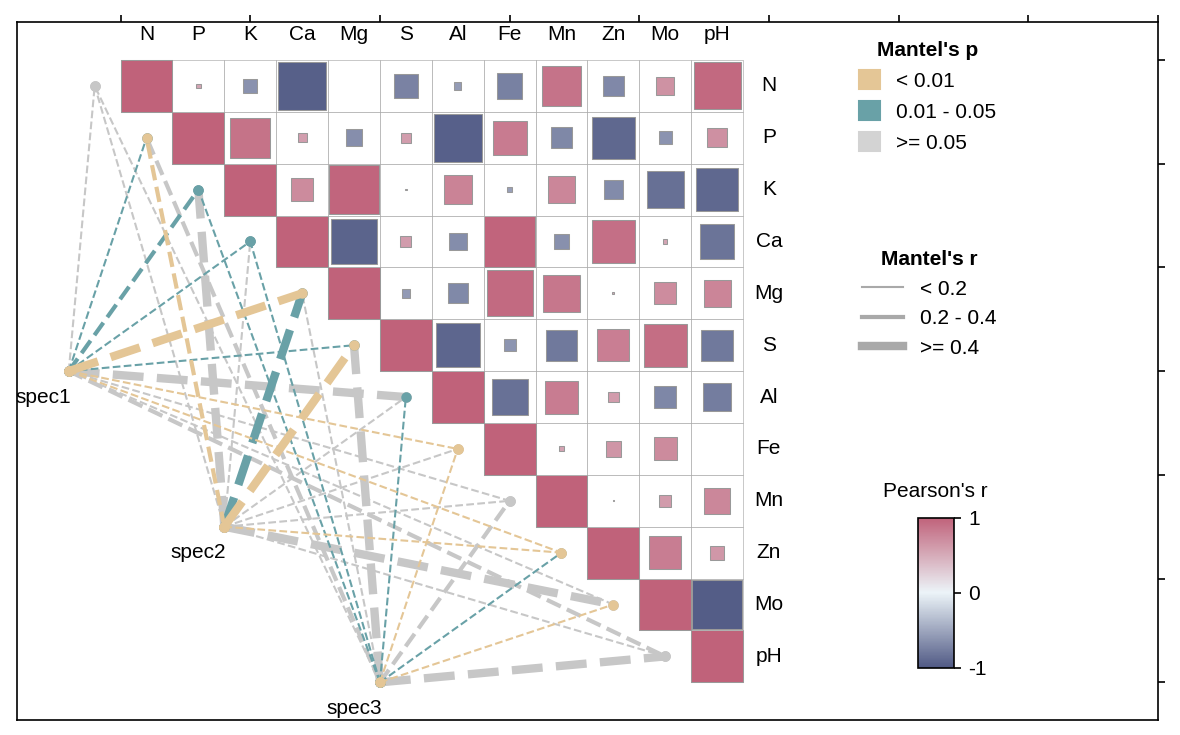

In [ ]:

def gradient_color(min_value, max_value, hex_colors, value):
    """根据 value 在 [min_value, max_value] 范围内的相对位置，计算渐变颜色"""
    if max_value == min_value:
        return mcolors.to_hex(mcolors.hex2color(hex_colors[len(hex_colors) // 2]))
    normalized_value = np.clip((value - min_value) / (max_value - min_value), 0, 1)
    color_idx = int(normalized_value * (len(hex_colors) - 1))
    color_start, color_end = map(
        mcolors.hex2color,
        (hex_colors[color_idx], hex_colors[min(color_idx + 1, len(hex_colors) - 1)]),
    )
    interpolated_color = [
        (1 - (normalized_value % 1)) * s + (normalized_value % 1) * e
        for s, e in zip(color_start, color_end)
    ]
    return mcolors.to_hex(interpolated_color)

def calc_p_color(value):
    """根据 p 值选择对应的颜色。"""
    return "#e4c696" if value < 0.01 else "#69a1a7" if value < 0.05 else "#c7c7c7"

def calc_r_width(value):
    """根据 r 值选择线条的宽度。"""
    return 1.0 if value < 0.2 else 2.0 if value < 0.4 else 4.0

def create_chart(ax):
    """创建相关性网络热图，展示特征间的相关性、物种和特征的显著性与关系强度。"""
    # 特征标签（示例数据，可替换为真实特征）
    feature_labels = "N P K Ca Mg S Al Fe Mn Zn Mo pH".split()
    feature_count = len(feature_labels)
    # 物种标签（示例数据，可替换为真实物种）
    spec_labels = ["spec1", "spec2", "spec3"]

    # 生成模拟数据（可替换为真实数据）
    np.random.seed(10)
    # 特征间相关系数矩阵（Pearson）
    pearson_data = np.random.uniform(-1, 1, (feature_count, feature_count))
    np.fill_diagonal(pearson_data, 1)  # 对角线为 1（自身相关）
    # 物种-特征的 p 值矩阵
    p_data = np.random.beta(0.8, 5, (len(spec_labels), feature_count))
    # 物种-特征的 r 值矩阵
    r_data = np.random.uniform(-1, 1, (len(spec_labels), feature_count))

    # 绘制物种-特征的连接线和标签
    spec_pos_y = np.linspace(0, feature_count, len(spec_labels) + 2).tolist()
    for i, spec in enumerate(spec_labels):
        # 绘制物种标签
        ax.text(
            spec_pos_y[i + 1] - 4.5,
            spec_pos_y[-2 - i] - 3.5,
            spec,
            va="center",
            ha="center",
        )
        # 绘制物种-特征的连接线
        for j in range(feature_count):
            ax.plot(
                [spec_pos_y[i + 1] - 4, -0.5 + j],
                [spec_pos_y[-2 - i] - 3, feature_count - j - 0.5],
                linestyle="--",
                linewidth=calc_r_width(r_data[i, j]),
                color=calc_p_color(p_data[i, j]),
                zorder=1 / p_data[i, j],
                marker="o",
                markersize=4,
            )

    # 绘制相关性矩阵的方块
    pearson_colors = ["#515a85", "#ecf4f8", "#c0627a"]
    for i in range(feature_count):
        for j in range(i, feature_count):
            size = pearson_data[i, j] * 1  # 控制方块大小
            color = gradient_color(-1, 1, pearson_colors, pearson_data[i, j])
            # 绘制白色背景方块（边框）
            ax.add_patch(
                patches.Rectangle(
                    (feature_count - i - 1, j),
                    1,
                    1,
                    linewidth=0.25,
                    edgecolor="#999999",
                    facecolor="#ffffff",
                )
            )
            # 绘制颜色方块（填充）
            ax.add_patch(
                patches.Rectangle(
                    (feature_count - i - 0.5 - size / 2, j + 0.5 - size / 2),
                    size,
                    size,
                    linewidth=0.5,
                    edgecolor="#999999",
                    facecolor=color,
                )
            )

    # 绘制特征标签
    for i, label in enumerate(feature_labels):
        ax.text(0.5 + i, 0.5 + feature_count, label, va="center", ha="center")
        ax.text(
            feature_count + 0.5,
            feature_count - 0.5 - i,
            label,
            va="center",
            ha="center",
        )

    # 绘制 Mantel's p 图例
    font_prop = FontProperties(weight="bold")
    mantel_p_handles = [
        patches.Patch(color="#e4c696", label="< 0.01"),
        patches.Patch(color="#69a1a7", label="0.01 - 0.05"),
        patches.Patch(color="lightgrey", label=">= 0.05"),
    ]
    mantel_p_legend = ax.legend(
        handles=mantel_p_handles,
        title="Mantel's p",
        bbox_to_anchor=(0.875, 1.0),
        handleheight=1.0,
        handlelength=1.0,
    )
    mantel_p_legend.get_frame().set_edgecolor("#ffffff")
    mantel_p_legend.get_title().set_font_properties(font_prop)
    ax.add_artist(mantel_p_legend)

    # 绘制 Mantel's r 图例
    mantel_r_handles = [
        mlines.Line2D([], [], color="#a9a9a9", linewidth=1, label="< 0.2"),
        mlines.Line2D([], [], color="#a9a9a9", linewidth=2, label="0.2 - 0.4"),
        mlines.Line2D([], [], color="#a9a9a9", linewidth=4, label=">= 0.4"),
    ]
    mantel_r_legend = ax.legend(
        handles=mantel_r_handles,
        title="Mantel's r",
        bbox_to_anchor=(0.875, 0.7),
    )
    mantel_r_legend.get_frame().set_edgecolor("#ffffff")
    mantel_r_legend.get_title().set_font_properties(font_prop)
    ax.add_artist(mantel_r_legend)

    # 绘制相关性矩阵方块的颜色条
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", pearson_colors)
    norm = mcolors.Normalize(vmin=-1.0, vmax=1.0)
    cbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=fig.add_axes([0.775, 0.1, 0.03, 0.2]),
    )
    cbar.ax.set_title("Pearson's r", fontdict={"fontsize": 10}, loc="center", pad=10)

    # 设置轴属性
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.xaxis.tick_top()
    ax.yaxis.tick_right()
    ax.axis("equal")
    ax.set_xlim(-2, feature_count + 8)
    ax.set_ylim(-1, feature_count + 1)
    # ax.set_title("相关性网络热图", pad=20)

if __name__ == "__main__":
    load_style()
    fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
    create_chart(ax)
    plt.tight_layout()
    plt.show()